<h3 style="text-align:center;">Simulating Rabi Reset</h3> 
This code will simulate the phenomenan of Rabi reset of the cavity. We will always denote the storage cavity as mode a, readout resonator as mode b, and the transmon qubit as mode c. The storage cavity is extremely long lived - good for doing quantum tasks - but the problem remains to ecavuate the photons from it fast after its run is complete.   

In [17]:
import dynamiqs as dq
import jax.numpy as jnp
from pathlib import Path
import json
import matplotlib.pyplot as plt

param_path = Path("../params.json")
with open(param_path, "r") as f:
    params = json.load(f)
fmax = max(params["cavity_detuning"], params["qubit_detuning"], params["resonator_detuning"])

# Define the truncation of each mode
N_cavity = 10
N_qubit = 2
N_resonator = 10

# Define Dynamics related parameters 
tmax = 1/params["cavity_decay"]
td = 120
safe_cycle = 4

print(f" total time simulated is {tmax} us with {td} time steps")
print(f"Fastest dynamics cycle : {1/fmax} us and dt simulation is {tmax/td} us")
if 1/(safe_cycle*fmax) < tmax/td :
    print(f"Suggested safe td for accurate simulation is {int(tmax/(1/(fmax*safe_cycle)))}")
else:
    print(f"td is sufficient for accurate simulation")

 total time simulated is 1492.5373134328358 us with 120 time steps
Fastest dynamics cycle : 0.5 us and dt simulation is 12.437810945273633 us
Suggested safe td for accurate simulation is 11940


__1.a Defining the System (Hamiltonian and Decay)__ \
The Hamiltonian of the system can be approximated at various stages - depending on how much precision is desired - or how the elements are being driven. To start with, we write the absolute basic first approximation (known as H1) : 
$$ H_1 = \Delta_a a^{\dagger}a + \Delta_b b^{\dagger}b + \Delta_c c^{\dagger}c - \frac{\chi_{cc}}{2} c^{\dagger 2}c^2 - \frac{\chi_{bb}}{2} b^{\dagger 2}b^2 - \frac{\chi_{aa}}{2} a^{\dagger 2}a^2 $$

$$ H_2 = -\chi_{ab} a^{\dagger}a b^{\dagger}b -\chi_{ac} a^{\dagger}a c^{\dagger}c --\chi_{bc} b^{\dagger}b c^{\dagger}c$$

These two terms are omnipresent - always there irrespective of anything. Therefore, we can be sure that always the first approximation of the Hamiltonian will be $ H_{\text{first}} = H_1 + H_2 $. There is a third drive term that will be added to it 

$$ H_{drive} = \zeta_a (a + a^{\dagger}) + \zeta_b (b + b^{\dagger}) + \zeta_c (c + c^{\dagger})$$

when you decide to drive your element $k$ with drive amplitude $\zeta_k$ and detuning $\Delta_k$.

In [18]:
# Computing the model system parameters from params


# Defining the system operators
a = dq.destroy(N_cavity);  a_dag = a.dag() 
b = dq.destroy(N_resonator); b_dag = b.dag()
c = dq.destroy(N_qubit); c_dag = c.dag()

a = dq.tensor(a, dq.eye(N_resonator), dq.eye(N_qubit))
b = dq.tensor(dq.eye(N_cavity), b, dq.eye(N_qubit))
c = dq.tensor(dq.eye(N_cavity), dq.eye(N_resonator), c)

a_dag = dq.tensor(a_dag, dq.eye(N_resonator), dq.eye(N_qubit))
b_dag = dq.tensor(dq.eye(N_cavity), b_dag, dq.eye(N_qubit))
c_dag = dq.tensor(dq.eye(N_cavity), dq.eye(N_resonator), c_dag)

# Defining the System Initial State
rho_a = dq.fock_dm(N_cavity, 1)
rho_b = dq.fock_dm(N_resonator, 0)
rho_c = dq.fock_dm(N_qubit, 0)
rho0 = dq.tensor(rho_a, rho_b, rho_c)

# Defining the System Hamiltonian
H1 = params["cavity_detuning"]*a_dag @ a + \
params["resonator_detuning"]*b_dag @ b + \
params["qubit_detuning"]*c_dag @ c - \
(params["qubit_anharmonicity"]/2)*c_dag @ c_dag @ c @ c - \
(params["cavity_self_kerr"]/2)*a_dag @ a_dag @ a @ a

H2 = - params["cavity_qubit_coupling"]*a_dag @ a @ c_dag @ c - \
- params["qubit_resonator_coupling"]*b_dag @ b @ c_dag @ c

Hdrive = params["cavity_drive_amp"]*(a_dag + a) + \
params["qubit_drive_amp"]*(c_dag + c) + \
params["resonator_drive_amp"]*(b_dag + b)
H_driven = H1 + H2 + Hdrive
H_undriven = H1 + H2

# Defining the System Dissipators and Observables
jump_ops = [jnp.sqrt(params["cavity_decay"])*a, jnp.sqrt(params["resonator_decay"])*b \
, jnp.sqrt(params["qubit_decay"])*c]
observables = [a_dag @ a, b_dag @ b, c_dag @ c]

# Defining the Scope of Simulation
tsave = jnp.linspace(0.0, tmax, td)
method = dq.method.Tsit5(rtol=1e-3, atol=1e-5)

# To see Rabi rest to work, we need to ensure 
# Theoretical Steasy State amplitudes : 
Ea = abs(params["cavity_drive_amp"]/(params["cavity_detuning"] + params["cavity_decay"]*1j/2))
Eb = abs(params["resonator_drive_amp"]/(params["resonator_detuning"] + params["resonator_decay"]*1j/2))

if params["qubit_resonator_coupling"]*Eb < params["resonator_decay"]/2 : 
    print("qubit-resonator is balanced for Rabi reset") 
if params["cavity_qubit_coupling"]*Ea < params["qubit_resonator_coupling"]*Eb : 
    print("cavity-qubit is balanced for Rabi reset")

print(f"a-c coupling is {params["cavity_qubit_coupling"]*Ea} and b-c coupling is {params["qubit_resonator_coupling"]*Eb}")

qubit-resonator is balanced for Rabi reset
a-c coupling is 0.0 and b-c coupling is 0.0


In [19]:
# Running the Simulation
result1 = dq.mesolve(H_driven, jump_ops, rho0, tsave=tsave, exp_ops = observables)
print(result1)
result2 = dq.mesolve(H_undriven, jump_ops, rho0, tsave=tsave, exp_ops = observables)
print(result1)

|██████████| 100.0% ◆ elapsed 10.31s ◆ remaining 0.00ms  


==== MESolveResult ====
Method  : Tsit5
Infos   : 7242 steps (7242 accepted, 0 rejected)
States  : QArray complex64 (120, 200, 200) | 36.6 Mb
Expects : Array complex64 (3, 120) | 2.8 Kb


|██████████| 100.0% ◆ elapsed 30.97ms ◆ remaining 0.00ms

==== MESolveResult ====
Method  : Tsit5
Infos   : 7242 steps (7242 accepted, 0 rejected)
States  : QArray complex64 (120, 200, 200) | 36.6 Mb
Expects : Array complex64 (3, 120) | 2.8 Kb


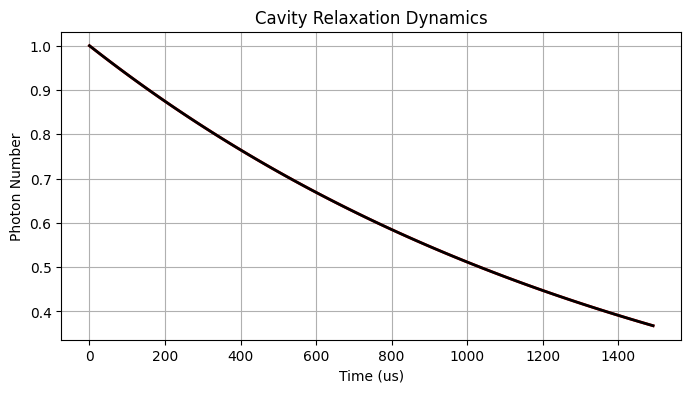

In [20]:
# Analysing the results
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(tsave, result1.expects[0].real, linewidth=2, color = "r")
ax.plot(tsave, result2.expects[0].real, linewidth=2, color = "k")
ax.set_xlabel("Time (us)")
ax.set_ylabel("Photon Number")
ax.set_title("Cavity Relaxation Dynamics")
ax.grid()